In [3]:
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt

In [4]:
npr.random((1,5))

array([[0.80741942, 0.71496286, 0.49438835, 0.41004808, 0.59774918]])

In [5]:
#Simulation matrices de n*p gaussiennes réelles standards

def normal_standard(n, p) : 

    U = npr.random((n,p))
    V = npr.random((n,p))

    X = np.sqrt(-2 * np.log(U))*np.cos(2*np.pi*V)

    return X 

In [73]:
normal_standard(1,5)

array([[-0.25207809,  0.94568933, -1.17603495,  0.7560647 ,  0.49313198]])

In [6]:
# Simulation d'un mouvement brownien standard
def mouvement_brownien(T, N):
    """
    Simule une trajectoire d'un mouvement brownien standard.
    Paramètres :
    - T : temps final
    - N : nombre de pas de temps

    Retourne :
    - t : tableau des temps
    - W : tableau des valeurs du mouvement brownien
    """

    dt = T / N
    t = np.linspace(0, T, N+1)
    W = np.zeros(N+1)

    dW = np.sqrt(dt) * normal_standard(1, N)[0] ; print(dW)

    for i in range(1, N+1):
        W[i] = W[i-1] + dW[i-1]

    return t, W

[ 0.01798779 -0.04405696 -0.03752188  0.03565664  0.02749635 -0.06306515
  0.03203501  0.05602832 -0.12780696  0.12630773 -0.02852776  0.09508153
  0.11112382 -0.02470153  0.07429775 -0.08107037 -0.0157247  -0.00925428
  0.04646371  0.01577722 -0.00577347  0.00276071  0.03787634 -0.08819253
  0.04182151  0.04897961 -0.21195722 -0.08010038 -0.20034703  0.07925551
  0.1286077   0.19027442 -0.0934     -0.01219049  0.04879672 -0.00198849
 -0.00040921 -0.04596829 -0.04568729  0.08977819  0.16209164 -0.04068598
 -0.01595099  0.03578425  0.10891124  0.18144545  0.09842731 -0.0940557
  0.07240607 -0.13829298  0.06047053 -0.02223679  0.06349416  0.0201866
 -0.02698948  0.12082484 -0.09592013  0.00582662 -0.05338959 -0.11857222
  0.04123361 -0.34795786 -0.23547306  0.15129705  0.02095198 -0.14416012
  0.05636792 -0.1254615  -0.03961761 -0.02935978  0.0040811   0.20281603
  0.11124153 -0.05146912  0.18319825  0.02893784 -0.10696072  0.03081672
 -0.10438183 -0.02104144 -0.05149197  0.16347949 -0.0

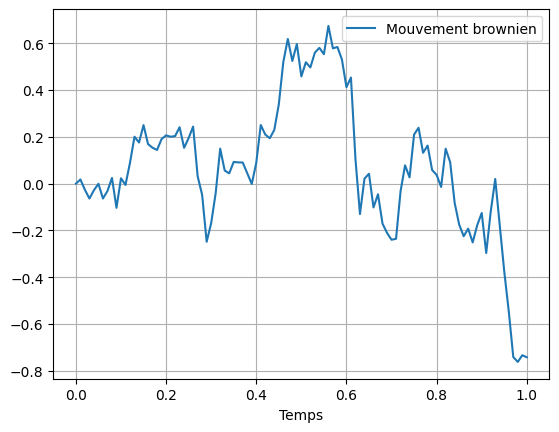

In [7]:
# Test 

t, W = mouvement_brownien(1, 100)

# Affichage
plt.plot(t, W, label='Mouvement brownien')
plt.xlabel('Temps')
plt.legend()
plt.grid()
plt.show()

[-8.49235971e-04  7.06371631e-03  1.85932177e-03 -1.51764842e-02
 -1.09198232e-02  3.10924849e-02 -2.13760622e-02  1.21460407e-02
  2.71047772e-02 -1.83568918e-02 -7.36483583e-02 -1.63175039e-02
  4.57194948e-03 -2.84380688e-03 -1.15353484e-04 -1.41215063e-02
  8.73944369e-03  1.96120276e-02 -4.29530410e-03 -5.85688084e-02
 -4.59833197e-02  3.33926615e-03  9.78441864e-03  5.35470270e-02
 -3.48570333e-02 -1.11146239e-03 -4.33702118e-02 -4.65068847e-02
 -2.10511995e-02  6.96034960e-02  2.00501258e-02 -3.83067383e-02
  5.69649378e-02  6.01841566e-02  1.19713412e-02  5.94750779e-02
 -1.36709318e-02 -6.33143399e-02 -1.90497949e-03  3.72505811e-03
  5.79176149e-02  1.09810203e-03 -1.95129389e-02 -1.46046759e-02
  1.07780374e-02 -3.44831622e-02 -6.79313235e-03  2.80440512e-02
 -9.25106622e-02  1.18730402e-02  4.75644986e-02 -4.83737909e-02
  2.19333473e-02  8.98703995e-03 -3.05329498e-02  1.76537410e-02
 -2.99340022e-02 -3.20491080e-02 -2.60563357e-02  1.07125918e-01
 -4.83901813e-02  5.71950

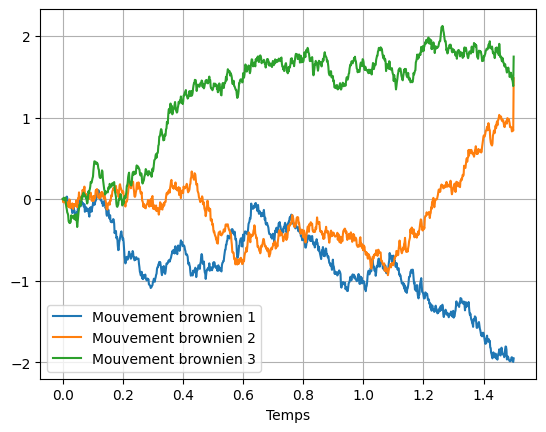

In [8]:
# Simulation des trajectoires Mouvement Bornien Standards Corrélés
T = 1.5   # Temps final
N = 1000  # Nombre de pas de temps
rho = 0.3
Gamma = np.linalg.cholesky([[1,rho,rho],
                            [rho,1,rho],
                            [rho,rho,1]])
# 1 : Simulation MB standards de dimension 3
t1, W1 = mouvement_brownien(T, N)
_, W2 = mouvement_brownien(T, N)
_, W3 = mouvement_brownien(T, N)

# 2 : corrélation des MB : 
for i in range (0, N):
    [W1[i],W2[i],W3[i]] = Gamma @ [W1[i],W2[i],W3[i]]
    
# Affichage
plt.plot(t1, W1, label='Mouvement brownien 1')
plt.plot(t1, W2, label='Mouvement brownien 2')
plt.plot(t1, W3, label='Mouvement brownien 3')
plt.xlabel('Temps')
plt.legend()
plt.grid()
plt.show()

Text(0.5, 0, 'W3(T)')

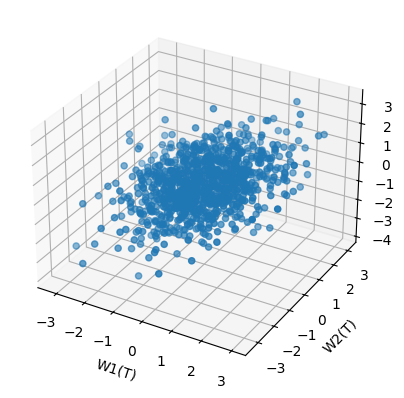

In [11]:
# Simulation du vecteur gaussien (W1(T), W2(T), W3(T)), centré, de matrice de var-cov Gamma
N = 1000
W=normal_standard(3, N)

rho = 0.3
Gamma = [[1,rho,rho],
        [rho,1,rho],
        [rho,rho,1]]

A = np.linalg.cholesky(Gamma)

B = A @ W 

fig = plt.figure()
ax=fig.add_subplot(projection='3d')

ax.scatter(B[0], B[1], B[2])

ax.set_xlabel('W1(T)')
ax.set_ylabel('W2(T)')
ax.set_zlabel('W3(T)')


In [ ]:
# Simulation de P1 par la méthode de Monte Carlo

def LGN_uniforme(N) :
    """
    Simule l'esperance d'une suite de v.a. iid.
    Paramètres :
    - X : vecteur de v.a. 
    - T : temps final
    - N : nombre de pas de temps

    Retourne :
    - E : Esperance des (Xi)i à une précision 1/sqrt(N)
    """

    U = np.random.uniform(0, 1, N) # génère N v.a. uniformes sur [0,1] (à priori iid)

    return (1/N) * np.sum(U)

In [ ]:
# test
N = 10000000
LGN_uniforme(N)

# on a bien une précision à ~10^-4 :DD